In [1]:
from tensorflow.keras.models import load_model

model = load_model("../models/damage_classifier_v2.keras")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,543,799 (17.33 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 329,486 (1.26 MB)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_generator = test_datagen.flow_from_directory(
    "../data/damage_images",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 1437 images belonging to 6 classes.


In [6]:
predictions = model.predict(test_generator)

y_pred = predictions.argmax(axis=1)

y_true = test_generator.classes

45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 813ms/step


In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.0738


In [9]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

        Crack       0.00      0.00      0.00        34
         Dent       0.00      0.00      0.00       415
    Flat_tire       0.07      1.00      0.14       106
Glass_shatter       0.00      0.00      0.00       237
  Lamp_broken       0.00      0.00      0.00       176
      Scratch       0.00      0.00      0.00       469

     accuracy                           0.07      1437
    macro avg       0.01      0.17      0.02      1437
 weighted avg       0.01      0.07      0.01      1437



c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

cm

array([[  0,   0,  34,   0,   0,   0],
       [  0,   0, 415,   0,   0,   0],
       [  0,   0, 106,   0,   0,   0],
       [  0,   0, 237,   0,   0,   0],
       [  0,   0, 176,   0,   0,   0],
       [  0,   0, 469,   0,   0,   0]], dtype=int64)

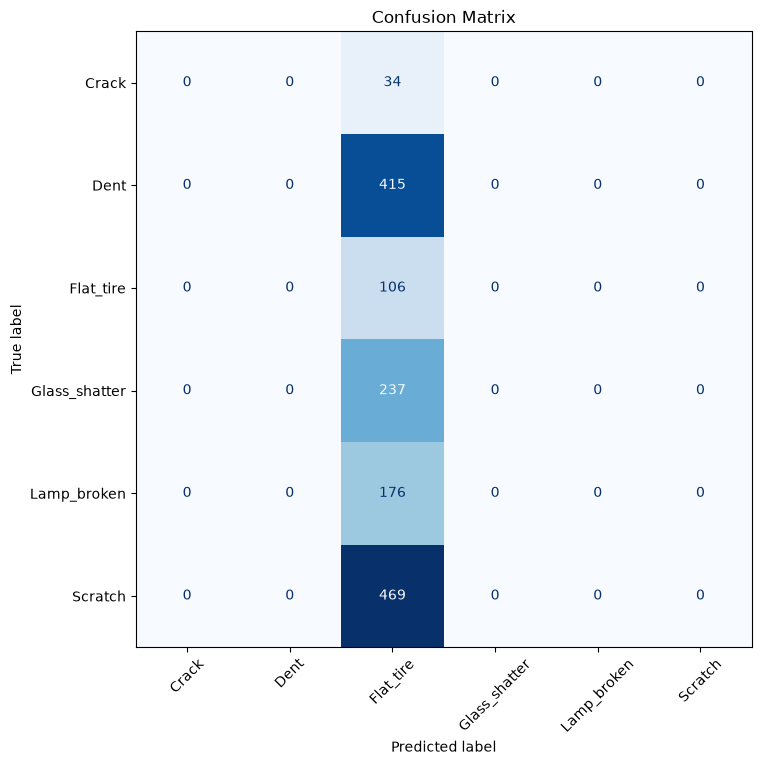

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.xticks(rotation=45)

plt.show()

In [12]:
import numpy as np

confidence = np.max(predictions, axis=1)

print(confidence.mean())

0.28933868


In [13]:
errors = np.where(y_true != y_pred)[0]

len(errors)

1331

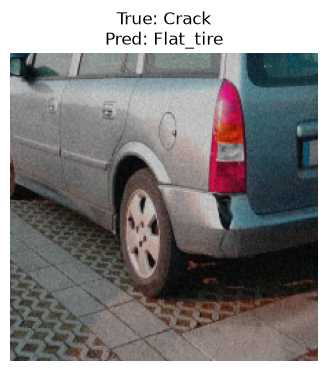

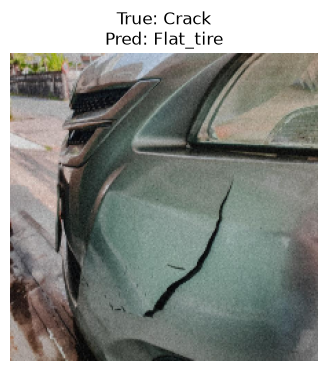

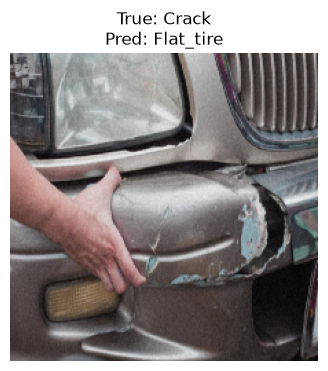

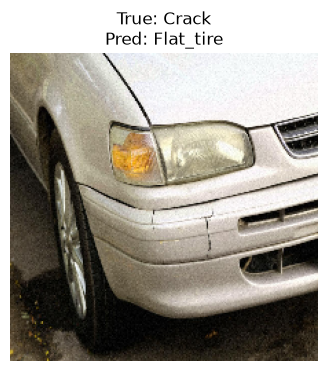

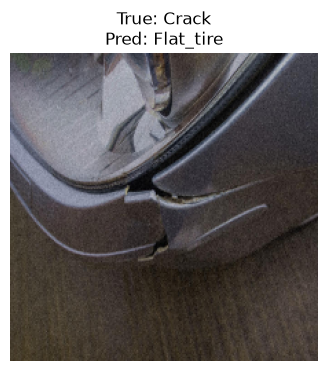

In [14]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

for i in errors[:5]:

    path = test_generator.filepaths[i]

    img = load_img(path, target_size=(224,224))

    plt.figure(figsize=(4,4))
    plt.imshow(img)

    plt.title(
        f"True: {class_names[y_true[i]]}\n"
        f"Pred: {class_names[y_pred[i]]}"
    )

    plt.axis("off")
    plt.show()

In [15]:
print(test_generator.class_indices)

{'Crack': 0, 'Dent': 1, 'Flat_tire': 2, 'Glass_shatter': 3, 'Lamp_broken': 4, 'Scratch': 5}


In [16]:
predictions[:3]

array([[0.1559253 , 0.16434309, 0.28921705, 0.06156826, 0.0990613 ,
        0.229885  ],
       [0.1556316 , 0.16430376, 0.28942874, 0.06163323, 0.09903035,
        0.22997239],
       [0.15542422, 0.1642124 , 0.28932223, 0.06153621, 0.09896018,
        0.23054473]], dtype=float32)

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,543,799 (17.33 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 329,486 (1.26 MB)

In [24]:
import tensorflow as tf

val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/damage_images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 7200 files belonging to 6 classes.
Using 1440 files for validation.


In [25]:
predictions = model.predict(val_ds)

45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 760ms/step


In [19]:
test_generator.reset()

predictions = model.predict(test_generator)

print(predictions[:5])

45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step
[[0.1559253  0.16434309 0.28921705 0.06156826 0.0990613  0.229885  ]
 [0.1556316  0.16430376 0.28942874 0.06163323 0.09903035 0.22997239]
 [0.15542422 0.1642124  0.28932223 0.06153621 0.09896018 0.23054473]
 [0.15525265 0.1644649  0.28929514 0.06126055 0.09849799 0.23122872]
 [0.15577088 0.16449358 0.2891345  0.06151361 0.09899478 0.23009273]]


In [26]:
import numpy as np

y_true = np.concatenate([y.numpy() for _, y in val_ds])
y_pred = np.argmax(predictions, axis=1)

In [28]:
import numpy as np

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = np.concatenate(
    [
        y.numpy()
        for _, y in val_ds
    ]
)

print(y_true.shape)
print(y_pred.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 742ms/step
(1440,)
(1440,)


In [29]:
import json

with open(
    "../models/class_names.json",
    "r"
) as f:
    class_names = json.load(f)

print(class_names)

['Crack', 'Dent', 'Flat_tire', 'Glass_shatter', 'Lamp_broken', 'Scratch']


In [30]:
from sklearn.metrics import classification_report


report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)


print(report)

               precision    recall  f1-score   support

        Crack       0.00      0.00      0.00         0
         Dent       0.00      0.00      0.00         0
    Flat_tire       0.00      0.00      0.00         0
Glass_shatter       0.00      0.00      0.00         0
  Lamp_broken       0.00      0.00      0.00         0
      Scratch       1.00      0.72      0.84      1440

     accuracy                           0.72      1440
    macro avg       0.17      0.12      0.14      1440
 weighted avg       1.00      0.72      0.84      1440



c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

cm

array([[   0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0],
       [  67,  152,   71,   28,   86, 1036]], dtype=int64)

<Figure size 800x800 with 0 Axes>

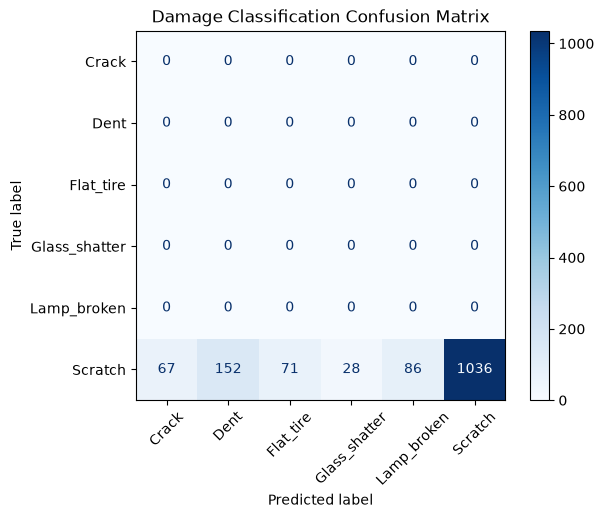

In [32]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay


plt.figure(
    figsize=(8,8)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)


disp.plot(
    cmap="Blues",
    xticks_rotation=45
)


plt.title(
    "Damage Classification Confusion Matrix"
)


plt.show()

In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Accuracy: {accuracy:.2%}"
)

Accuracy: 71.94%


In [21]:
from PIL import Image
import numpy as np

img = Image.open("../data/test_images/flat_reifen.jpg")
img = img.convert("RGB")
img = img.resize((224,224))

img_array = np.array(img, dtype=np.float32)

# Если при обучении был rescale=1./255,
# то добавь эту строку:
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

print(pred)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[0.15533936 0.16438854 0.2891901  0.06135937 0.09883515 0.23088749]]
2


In [23]:
from pathlib import Path

model_path = Path("../models/damage_classifier_v2.keras").resolve()

print(model_path)
print(model_path.exists())
print(model_path.stat().st_size)

D:\New_26\AI_Assistant_Car_Pricing\models\damage_classifier_v2.keras
True
19042557
